In [4]:
import torch
import torchvision
import torchvision.transforms as T
import os
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights

In [5]:
os.chdir("../")
os.getcwd()
os.chdir("../")
os.getcwd()


'/home/selc-a4-sr2/Solar_Rooftop_Detection'

In [6]:
from Solar_Rooftop_Detection.get_bounding_box_cordinates import bounding_box

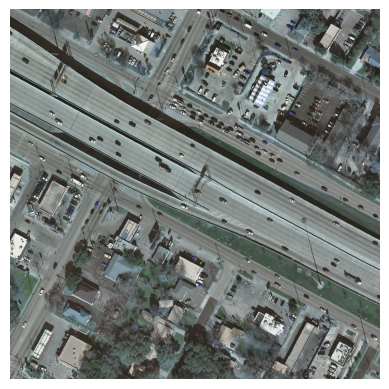

In [7]:
demo_img = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/images/0.jpg")
demo_img = cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB)
import matplotlib.pyplot as plt
plt.imshow(demo_img)
plt.axis('off')
plt.show()

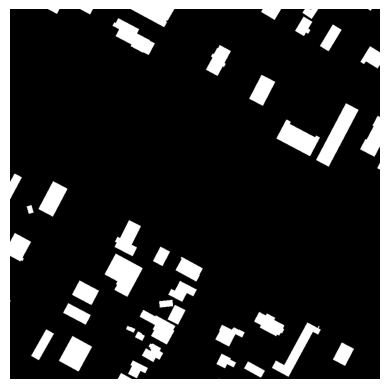

In [8]:
demo_mask = cv2.imread("/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/masks/0.jpg",cv2.IMREAD_GRAYSCALE)
plt.imshow(demo_mask, cmap='gray')
plt.axis('off')
plt.show()

In [9]:
import cv2
import numpy as np

def extract_individual_objects(input_mask):
    # Ensure the input is a binary mask (0 and 255 values)
    _, binary_mask = cv2.threshold(input_mask, 127, 255, cv2.THRESH_BINARY)

    # Find contours (connected components) in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # List to hold individual object masks
    object_masks = []
    bounding_boxes = []

    # Iterate over each contour to create an individual mask
    for contour in contours:
        # Create a blank mask with the same size as the original mask
        object_mask = np.zeros_like(binary_mask)
        
        x, y, w, h = cv2.boundingRect(contour)
        bounding_boxes.append((x, y, x+w, y+h))
        
        # Draw the current contour on the object mask (white)
        cv2.drawContours(object_mask, [contour], -1, (255), thickness=cv2.FILLED)

        # Append the object mask to the list
        object_masks.append(object_mask)

    return object_masks, bounding_boxes

In [10]:
demo_mask.shape

(1024, 1024)

In [11]:
multiple_masks, bb = extract_individual_objects(demo_mask)
len(multiple_masks), len(bb)

(45, 45)

In [12]:
M = np.array(multiple_masks)
M

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [13]:
M.shape

(45, 1024, 1024)

In [14]:
multiple_masks[0].shape

(1024, 1024)

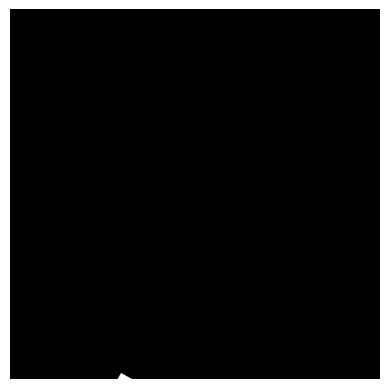

In [15]:
plt.imshow(multiple_masks[1], cmap='gray')
plt.axis('off')
plt.show()

In [19]:

# Define the dataset
class RooftopDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.images_dir = os.path.join(root, 'images')
        self.masks_dir = os.path.join(root, 'masks')
        self.imgs = sorted([f for f in os.listdir(self.images_dir)])
        self.masks = sorted([f for f in os.listdir(self.masks_dir)])

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.imgs[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = T.ToTensor()(img)

        # Load multi-instance mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # # Extract unique objects (assuming different objects have different pixel values)
        # obj_ids = np.unique(mask)[1:]  # Ignore background (0)
        # masks = (mask == obj_ids[:, None, None]).astype(np.uint8)  # Convert to binary masks

        # # Compute bounding boxes for each object
        # boxes = bounding_box(mask)
        
        # mask = np.where(mask > 0, 1, 0).astype(np.uint8)
        
        # mask = torch.as_tensor(mask, dtype=torch.uint8).unsqueeze(0) # Add channel dimension
        
        masks, boxes = extract_individual_objects(mask)
        
        if not masks or not boxes:
            print(f"Mask failed to load for image {img_path}")
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            masks = torch.zeros((0, 1024, 1024), dtype=torch.uint8)
            labels = torch.zeros((0,), dtype=torch.int64)
        else :            
            masks = np.stack(masks, axis=0)
            masks = torch.from_numpy(masks).to(dtype=torch.uint8)
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(boxes),), dtype=torch.int64)  # Assume all belong to class 1
            
        print(len(masks), len(boxes))

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx])
        }
        if self.transforms is not None:
            img, target = self.transforms(img, target)


        return img, target

    def __len__(self):
        return len(self.imgs)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    
root_dir = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/" 

dataset = RooftopDataset(root_dir)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
# data_loader


# Load a pre-trained Mask R-CNN model and modify for fine-tuning
def get_model_instance_segmentation(num_classes = 1):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1)

    # Modify the bounding box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Modify the mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # Default in Mask R-CNN
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model


num_classes = 2
my_model = get_model_instance_segmentation(num_classes = num_classes)

optimizer = torch.optim.Adam(my_model.parameters(), lr=0.0001)


def train_model(model, data_loader, optimizer, device, num_epochs=10):
    
    print("Training the model...") 
    model.to(device)    
    model.train()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0
        
        for images, targets in data_loader:
            print("images and targets are loaded", )
            
            images = [img.to(device) for img in images]
            
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            total_loss += losses.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")



train_model(my_model, data_loader, optimizer, device, num_epochs=10)

Training the model...
Epoch 1/10
10 10
295 295
33 33
117 117
images and targets are loaded
10 10
370 370
86 86
409 409
images and targets are loaded
15 15
14 14
84 84
215 215
images and targets are loaded
53 53
14 14
46 46
86 86
images and targets are loaded
24 24
4 4
53 53
14 14
images and targets are loaded
31 31
45 45
17 17
51 51
images and targets are loaded
17 17
20 20
80 80
3 3
images and targets are loaded
2 2
1 1
13 13
30 30
images and targets are loaded
90 90
48 48
78 78
21 21
images and targets are loaded
63 63
11 11
47 47
14 14
images and targets are loaded
Mask failed to load for image /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/images/2190.jpg
0 0
32 32
39 39
90 90
images and targets are loaded
138 138
17 17
9 9
13 13
images and targets are loaded
59 59
169 169
22 22
21 21
images and targets are loaded
Mask failed to load for image /home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/images/1368.jpg
0 0
22 22
42 42
205 205
images and target

In [ ]:
num_classes = 2

In [1]:
## Ex - 1

In [ ]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset

# Placeholder for your functions (replace with your actual implementations)
def split_masks(mask):
    # Takes a 1024x1024 grayscale mask and returns a list of binary instance masks
    # Example output: [mask1, mask2, ...], each 1024x1024
    pass

def bounding_box(mask):
    # Takes a 1024x1024 grayscale mask and returns a list of bounding boxes
    # Example output: [[x_min1, y_min1, x_max1, y_max1], [x_min2, y_min2, x_max2, y_max2], ...]
    pass

class RooftopDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.images_dir = os.path.join(root, 'images')
        self.masks_dir = os.path.join(root, 'masks')
        self.imgs = sorted([f for f in os.listdir(self.images_dir)])
        self.masks = sorted([f for f in os.listdir(self.masks_dir)])

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.imgs[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = T.ToTensor()(img)  # Shape: (3, 1024, 1024)

        # Load multi-instance mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # Shape: (1024, 1024)

        # Get all instance masks using your function
        instance_masks = split_masks(mask)  # List of 1024x1024 binary masks
        
        if not instance_masks:  # Handle case with no rooftops
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            masks = torch.zeros((0, 1024, 1024), dtype=torch.uint8)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            # Get all bounding boxes using your function
            boxes = bounding_box(mask)  # List of [x_min, y_min, x_max, y_max]
            boxes = torch.as_tensor(boxes, dtype=torch.float32)  # Shape: (num_instances, 4)

            # Ensure the number of boxes matches the number of masks
            assert len(boxes) == len(instance_masks), f"Mismatch: {len(boxes)} boxes vs {len(instance_masks)} masks"

            # Stack instance masks into a tensor
            masks = np.stack(instance_masks, axis=0)  # Shape: (num_instances, 1024, 1024)
            masks = torch.as_tensor(masks, dtype=torch.uint8)  # Shape: (num_instances, 1024, 1024)

            # Assign class labels (all 1 for rooftops)
            labels = torch.ones((len(instance_masks),), dtype=torch.int64)  # Shape: (num_instances,)

        # Prepare target dictionary for Mask R-CNN
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([idx])
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.imgs)

'/home/selc-a4-sr2/Solar_Rooftop_Detection/BaseLineModels'

In [4]:
os.chdir("../")
os.getcwd()

'/home/selc-a4-sr2/Solar_Rooftop_Detection'

In [5]:
os.listdir(os.getcwd())

['requirements.txt',
 'Arial_test_images',
 'output_images',
 '.git',
 'Arial_validation_images',
 'sam_vit_b.pth',
 'ReadMe.MD',
 'checkpoints',
 '.gitignore',
 'Solar_Rooftop_Detection',
 'BaseLineModels',
 'Arial_images_1024_1024',
 'demo.py',
 'Solar_rooftop_Detection_indian_images',
 'test.ipynb',
 'logs']

In [47]:
# Define the dataset
class RooftopDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.images_dir = os.path.join(root, 'images')
        self.masks_dir = os.path.join(root, 'masks')
        self.imgs = sorted([f for f in os.listdir(self.images_dir)])
        self.masks = sorted([f for f in os.listdir(self.masks_dir)])

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.imgs[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = T.ToTensor()(img)

        # Load multi-instance mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # # Extract unique objects (assuming different objects have different pixel values)
        # obj_ids = np.unique(mask)[1:]  # Ignore background (0)
        # masks = (mask == obj_ids[:, None, None]).astype(np.uint8)  # Convert to binary masks

        # Compute bounding boxes for each object
        boxes = bounding_box(mask)
        mask = np.where(mask > 0, 1, 0).astype(np.uint8)
        mask = torch.as_tensor(mask, dtype=torch.uint8).unsqueeze(0) # Add channel dimension
        

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((1,), dtype=torch.int64)  # Assume all belong to class 1

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": torch.as_tensor(mask, dtype=torch.uint8),
            "image_id": torch.tensor([idx])
        }

        return img, target

    def __len__(self):
        return len(self.imgs)

In [48]:
os.getcwd()

'/home'

In [49]:
root_dir = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/" 
dataset = RooftopDataset(root_dir)
data_loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
data_loader

In [50]:
t_image, ex= dataset[0]
t_image

tensor([[[0.4784, 0.4706, 0.4745,  ..., 0.2588, 0.2824, 0.3961],
         [0.4706, 0.5059, 0.4745,  ..., 0.2235, 0.3294, 0.3294],
         [0.4902, 0.4706, 0.4784,  ..., 0.3843, 0.3176, 0.2431],
         ...,
         [0.1922, 0.3333, 0.3882,  ..., 0.4039, 0.3608, 0.3647],
         [0.1020, 0.5294, 0.5059,  ..., 0.3255, 0.3843, 0.3882],
         [0.1608, 0.4353, 0.4863,  ..., 0.4157, 0.3569, 0.3451]],

        [[0.5020, 0.4941, 0.4902,  ..., 0.2588, 0.2863, 0.4000],
         [0.4941, 0.5294, 0.4902,  ..., 0.2235, 0.3333, 0.3333],
         [0.5098, 0.4902, 0.4980,  ..., 0.3843, 0.3176, 0.2431],
         ...,
         [0.1961, 0.3373, 0.3882,  ..., 0.4627, 0.4196, 0.4235],
         [0.1098, 0.5373, 0.5137,  ..., 0.3843, 0.4431, 0.4471],
         [0.1686, 0.4431, 0.4941,  ..., 0.4745, 0.4157, 0.4039]],

        [[0.4863, 0.4784, 0.4863,  ..., 0.2510, 0.2667, 0.3804],
         [0.4784, 0.5137, 0.4863,  ..., 0.2157, 0.3137, 0.3137],
         [0.4941, 0.4745, 0.4824,  ..., 0.3765, 0.3098, 0.

In [51]:
t_image.shape

torch.Size([3, 1024, 1024])

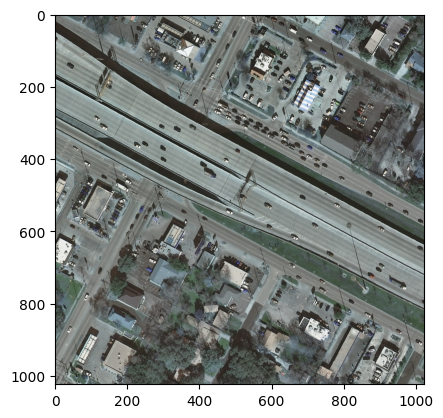

In [52]:
import matplotlib.pyplot as plt
plt.imshow(t_image.permute(1,2,0))

In [53]:
len(ex["boxes"]), print(ex)

{'boxes': tensor([[ 578., 1023.,  580., 1024.],
        [ 298., 1007.,  337., 1024.],
        [ 648.,  975.,  705., 1020.],
        [ 327.,  973.,  382., 1022.],
        [ 571.,  954.,  626.,  994.],
        [ 365.,  926.,  424.,  977.],
        [ 894.,  923.,  952.,  988.],
        [ 135.,  905.,  227., 1003.],
        [ 346.,  892.,  373.,  918.],
        [  59.,  886.,  122.,  972.],
        [ 321.,  877.,  347.,  896.],
        [ 568.,  874.,  649.,  934.],
        [ 725.,  868.,  860., 1018.],
        [ 676.,  838.,  759.,  906.],
        [ 359.,  833.,  458.,  928.],
        [ 436.,  819.,  486.,  874.],
        [ 147.,  814.,  223.,  874.],
        [   0.,  806.,    2.,  810.],
        [ 413.,  805.,  451.,  826.],
        [ 438.,  752.,  517.,  810.],
        [ 172.,  751.,  246.,  819.],
        [ 458.,  686.,  533.,  754.],
        [ 262.,  677.,  367.,  797.],
        [ 396.,  658.,  443.,  711.],
        [   0.,  620.,   58.,  699.],
        [ 289.,  584.,  362.,  684.],
  

(45, None)

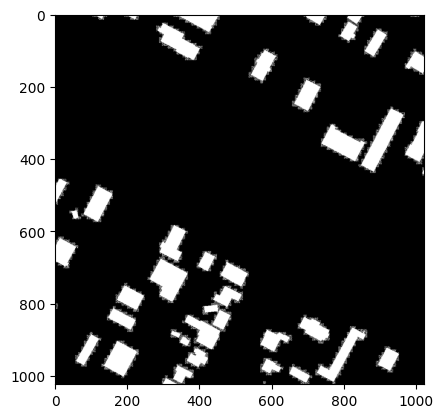

In [54]:
m = ex["masks"]
plt.imshow(m.permute(1,2,0), cmap='gray')

In [55]:
m.shape

torch.Size([1, 1024, 1024])

In [16]:
# Load a pre-trained Mask R-CNN model and modify for fine-tuning
def get_model_instance_segmentation(num_classes = 1):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)

    # Modify the bounding box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Modify the mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256  # Default in Mask R-CNN
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model

In [17]:
my_model = get_model_instance_segmentation()
my_model

/home/selc-a4-sr2/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/selc-a4-sr2/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
optimizer = torch.optim.Adam(my_model.parameters(), lr=0.0001)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(my_model.parameters(), lr=0.0001)

def train_model(model, data_loader, optimizer, device, num_epochs=10):
    
    print("Training the model...") 
    model.to(device)
    model.train()

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        total_loss = 0
        for images, targets in data_loader:
            print("images and targets are loaded", )
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            losses.backward()
            optimizer.step()

            total_loss += losses.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}")


In [33]:
for i in data_loader:
    one , exp = i
    break

In [35]:
len(one)

4

In [36]:
len(exp)

4

In [37]:
exp

({'boxes': tensor([]),
  'labels': tensor([1]),
  'masks': tensor([[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.uint8),
  'image_id': tensor([1148])},
 {'boxes': tensor([]),
  'labels': tensor([1]),
  'masks': tensor([[[0, 0, 0,  ..., 1, 1, 1],
           [0, 0, 0,  ..., 1, 1, 1],
           [0, 0, 0,  ..., 1, 1, 1],
           ...,
           [1, 1, 1,  ..., 0, 0, 0],
           [1, 1, 1,  ..., 0, 0, 0],
           [1, 1, 1,  ..., 0, 0, 0]]], dtype=torch.uint8),
  'image_id': tensor([32])},
 {'boxes': tensor([]),
  'labels': tensor([1]),
  'masks': tensor([[[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           ...,
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]], dtype=tor

In [31]:
train_model(my_model, data_loader, optimizer, device, num_epochs=10)


Training the model...
Epoch 1/10
images and targets are loaded


AssertionError: Expected target boxes to be a tensor of shape [N, 4], got torch.Size([0]).